# Cascade Machine Learning for Solar Water Heater Research

This notebook presents a two-stage cascade learning workflow for a solar water heater dataset.

The analysis follows a research-style sequence: raw data loading, cleaning, outlier removal, feature selection, model tuning, evaluation, residual analysis, and export of reusable CSV files and figures.

Stage 1 predicts the outlet temperature `Tout`. Stage 2 uses the predicted temperature to help predict the water outlet signal `Wout`.

The notebook is written so a student can follow the workflow step by step, while a colleague can reuse the exported tables and figures in separate software for post-processing or plotting.

## Notebook Roadmap

1. Load the augmented raw solar water heater data from CSV.
2. Clean the raw data before modeling.
3. Remove outliers from `Tout` and then from `Wout` in sequence.
4. Inspect the cleaned target trends and confirm the data shape.
5. Build the first model to predict outlet temperature `Tout`.
6. Use the predicted `Tout` as an input to the second model for `Wout`.
7. Tune both models with grid search and 5-fold cross-validation.
8. Report RMSE, MAE, R2, and adjusted R2 for the training folds and hold-out test set.
9. Check residual plots and error-propagation plots to understand where the models make mistakes.
10. Save figures, tables, and CSV files so the results can be reused in another analysis tool.

The main idea is that each stage helps the next one. That is why this is called a cascade model.

In [31]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict, cross_validate, train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'font.size': 11,
})

RANDOM_STATE = 42
DATA_PATH = Path('/Users/nirmal/Documents/np_dsci_codes/swh_ML/data/Thermosyphone_mode_60_degree_raw.csv')
FIGURE_DIR = Path('image') / 'swh_ml_f3'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [32]:
RENAME_MAP = {
    'time': 'time',
    'mode': 'mode',
    'I [W/m2]': 'irradiance_w_m2',
    'C': 'c',
    'f': 'f',
    'ha': 'ha',
    'v': 'v',
    'Kb': 'kb',
    'Xb': 'xb',
    'Ae': 'ae',
    'Ac': 'ac',
    'beta [degree]': 'beta_deg',
    'N': 'n',
    'm_dot [kg/sec]': 'mass_flow_kg_s',
    'Cp': 'cp',
    'Tau': 'tau',
    'alpha': 'alpha',
    'Ta [C]': 'ambient_c',
    'Ta [K]': 'ambient_k',
    'Tin [C]': 'tin_c',
    'Tin [K]': 'tin_k',
    'Tout [C]': 'tout_c',
    'Tout [K]': 'tout_k',
    'Tplate [C]': 'plate_c',
    'Tplate [K]': 'plate_k',
    'Ub [W/m2 K]': 'ub_w_m2k',
    'Ue [W/m2 K]': 'ue_w_m2k',
    'Fr': 'fr',
    'effi_thermosy': 'effi_thermosy',
    'effi_forced': 'effi_forced',
    'Ttank  [C]': 'tank_c',
    'Pin [Kpa]': 'pin_kpa',
    'Pout  [Kpa]': 'pout_kpa',
}

def load_raw_data(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=';')

def clean_data(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()
    df.columns = [column.strip() for column in df.columns]
    df = df.rename(columns=RENAME_MAP)
    df = df.drop_duplicates().reset_index(drop=True)
    df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce')
    for column in df.columns:
        if column not in {'time', 'mode'}:
            df[column] = pd.to_numeric(df[column], errors='coerce')
    df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
    numeric_columns = df.select_dtypes(include='number').columns
    df[numeric_columns] = df[numeric_columns].interpolate(method='linear', limit_direction='both')
    df[numeric_columns] = df[numeric_columns].ffill().bfill()
    df['time_minutes'] = (df['time'].dt.hour * 60) + df['time'].dt.minute + (df['time'].dt.second / 60.0)
    df['water_liters_step'] = df['mass_flow_kg_s'] * 600.0
    df['water_liters_cum'] = df['water_liters_step'].cumsum()
    return df

df_raw = load_raw_data(DATA_PATH)
df_raw.head()

,time,mode,I [W/m2],C,f,ha,v,Kb,Xb,Ae,Ac,beta [degree],N,m_dot [kg/sec],Cp,Tau,alpha,Ta [C],Ta [K],Tin [C],Tin [K],Tout [C],Tout [K],Tplate [C],Tplate [K],Ub [W/m2 K],Ue [W/m2 K],Fr,effi_thermosy,effi_forced,Ttank [C],Pin [Kpa],Pout [Kpa]
0,10:50:53,Thermosyphone,449.998271,342.760484,1.463368,9.498724,0.985026,0.043323,0.047327,0.597830,1.001159,60.002323,1.011636,0.000002,4180.001105,0.842617,0.949853,34.574473,307.598670,31.423055,304.555743,34.207959,307.022788,36.479214,309.776105,0.808734,0.477594,0.000478,0.000242,0.427901,37.287483,108.102092,103.297903
1,10:51:33,Thermosyphone,449.993931,342.760484,1.465109,9.506643,0.987809,0.048474,0.039978,0.599138,0.997061,60.001144,1.008186,0.000002,4180.003499,0.856499,0.964785,34.624484,307.621997,31.981383,305.244778,36.994138,310.580696,40.522788,313.621621,0.807685,0.494218,0.000642,0.000814,0.428374,37.482050,108.094761,103.299263
2,10:52:49,Thermosyphone,449.985563,342.760484,1.458881,9.496844,1.007236,0.045808,0.073214,0.606200,0.993906,59.994382,0.991684,0.000003,4179.994332,0.849297,0.967493,34.691467,307.700648,32.439139,305.677910,39.858698,313.174736,45.027513,317.955711,0.802614,0.481680,0.001377,0.000871,0.425879,37.307008,108.103326,103.300528
3,10:53:45,Thermosyphone,449.999701,342.760484,1.452760,9.515931,1.001151,0.034837,0.038716,0.598490,1.014233,60.008164,1.006889,0.000000,4180.007110,0.855559,0.954501,34.762657,307.776312,33.474515,306.299294,42.800503,316.252630,48.863804,322.028793,0.800978,0.467587,0.000279,0.000000,0.426298,37.500607,108.108407,103.300389
4,10:54:40,Thermosyphone,449.986967,342.760484,1.459580,9.517457,0.983191,0.049906,0.055914,0.615335,1.007124,60.000521,0.994784,0.000000,4180.001954,0.848083,0.980203,34.832105,307.852683,33.707356,306.994645,45.834997,319.080014,53.346836,326.223739,0.788828,0.484579,0.000656,0.000479,0.423089,37.716366,108.100324,103.300969


In [33]:
df = clean_data(df_raw)
df.head()

,time,mode,irradiance_w_m2,c,f,ha,v,kb,xb,ae,ac,beta_deg,n,mass_flow_kg_s,cp,tau,alpha,ambient_c,ambient_k,tin_c,tin_k,tout_c,tout_k,plate_c,plate_k,ub_w_m2k,ue_w_m2k,fr,effi_thermosy,effi_forced,tank_c,pin_kpa,pout_kpa,time_minutes,water_liters_step,water_liters_cum
0,1900-01-01 10:50:53,Thermosyphone,449.998271,342.760484,1.463368,9.498724,0.985026,0.043323,0.047327,0.597830,1.001159,60.002323,1.011636,0.000002,4180.001105,0.842617,0.949853,34.574473,307.598670,31.423055,304.555743,34.207959,307.022788,36.479214,309.776105,0.808734,0.477594,0.000478,0.000242,0.427901,37.287483,108.102092,103.297903,650.883333,0.001432,0.001432
1,1900-01-01 10:51:33,Thermosyphone,449.993931,342.760484,1.465109,9.506643,0.987809,0.048474,0.039978,0.599138,0.997061,60.001144,1.008186,0.000002,4180.003499,0.856499,0.964785,34.624484,307.621997,31.981383,305.244778,36.994138,310.580696,40.522788,313.621621,0.807685,0.494218,0.000642,0.000814,0.428374,37.482050,108.094761,103.299263,651.550000,0.001393,0.002825
2,1900-01-01 10:52:49,Thermosyphone,449.985563,342.760484,1.458881,9.496844,1.007236,0.045808,0.073214,0.606200,0.993906,59.994382,0.991684,0.000003,4179.994332,0.849297,0.967493,34.691467,307.700648,32.439139,305.677910,39.858698,313.174736,45.027513,317.955711,0.802614,0.481680,0.001377,0.000871,0.425879,37.307008,108.103326,103.300528,652.816667,0.002077,0.004902
3,1900-01-01 10:53:45,Thermosyphone,449.999701,342.760484,1.452760,9.515931,1.001151,0.034837,0.038716,0.598490,1.014233,60.008164,1.006889,0.000000,4180.007110,0.855559,0.954501,34.762657,307.776312,33.474515,306.299294,42.800503,316.252630,48.863804,322.028793,0.800978,0.467587,0.000279,0.000000,0.426298,37.500607,108.108407,103.300389,653.750000,0.000000,0.004902
4,1900-01-01 10:54:40,Thermosyphone,449.986967,342.760484,1.459580,9.517457,0.983191,0.049906,0.055914,0.615335,1.007124,60.000521,0.994784,0.000000,4180.001954,0.848083,0.980203,34.832105,307.852683,33.707356,306.994645,45.834997,319.080014,53.346836,326.223739,0.788828,0.484579,0.000656,0.000479,0.423089,37.716366,108.100324,103.300969,654.666667,0.000000,0.004902


In [34]:
dataset_summary = pd.DataFrame({
    'metric': [
        'rows',
        'original_columns',
        'modeling_columns',
        'missing_values_after_cleaning',
        'Tout mean',
        'Tout std',
        'Wout mean',
        'Wout std',
    ],
    'value': [
        len(df),
        len(RENAME_MAP),
        df.shape[1],
        int(df.isna().sum().sum()),
        float(df['tout_c'].mean()),
        float(df['tout_c'].std()),
        float(df['water_liters_cum'].mean()),
        float(df['water_liters_cum'].std()),
    ]
})

display(dataset_summary)
display(df[['time', 'time_minutes', 'irradiance_w_m2', 'mass_flow_kg_s', 'tout_c', 'water_liters_cum']].head())

,metric,value
0,rows,380.000000
1,original_columns,33.000000
2,modeling_columns,36.000000
3,missing_values_after_cleaning,0.000000
4,Tout mean,70.601567
5,Tout std,7.399299
6,Wout mean,18.321834
7,Wout std,18.539393


,time,time_minutes,irradiance_w_m2,mass_flow_kg_s,tout_c,water_liters_cum
0,1900-01-01 10:50:53,650.883333,449.998271,0.000002,34.207959,0.001432
1,1900-01-01 10:51:33,651.550000,449.993931,0.000002,36.994138,0.002825
2,1900-01-01 10:52:49,652.816667,449.985563,0.000003,39.858698,0.004902
3,1900-01-01 10:53:45,653.750000,449.999701,0.000000,42.800503,0.004902
4,1900-01-01 10:54:40,654.666667,449.986967,0.000000,45.834997,0.004902


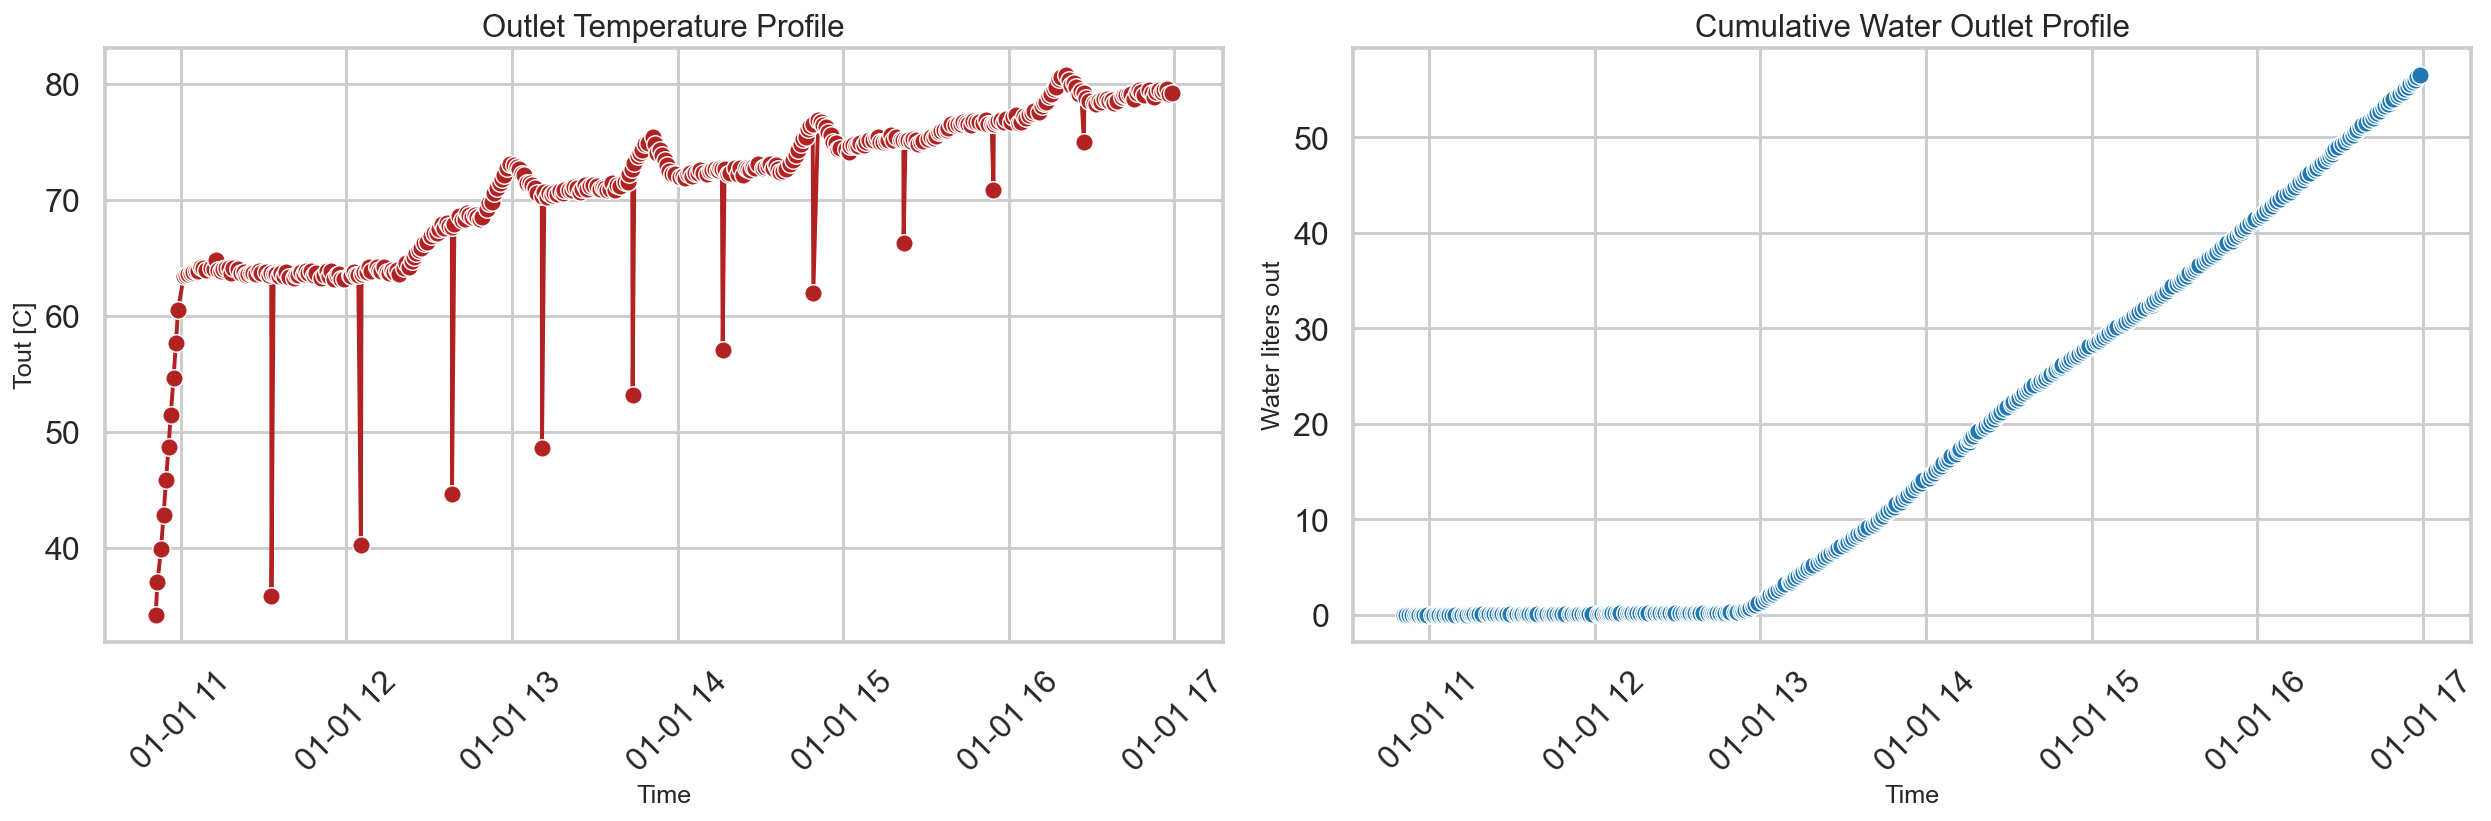

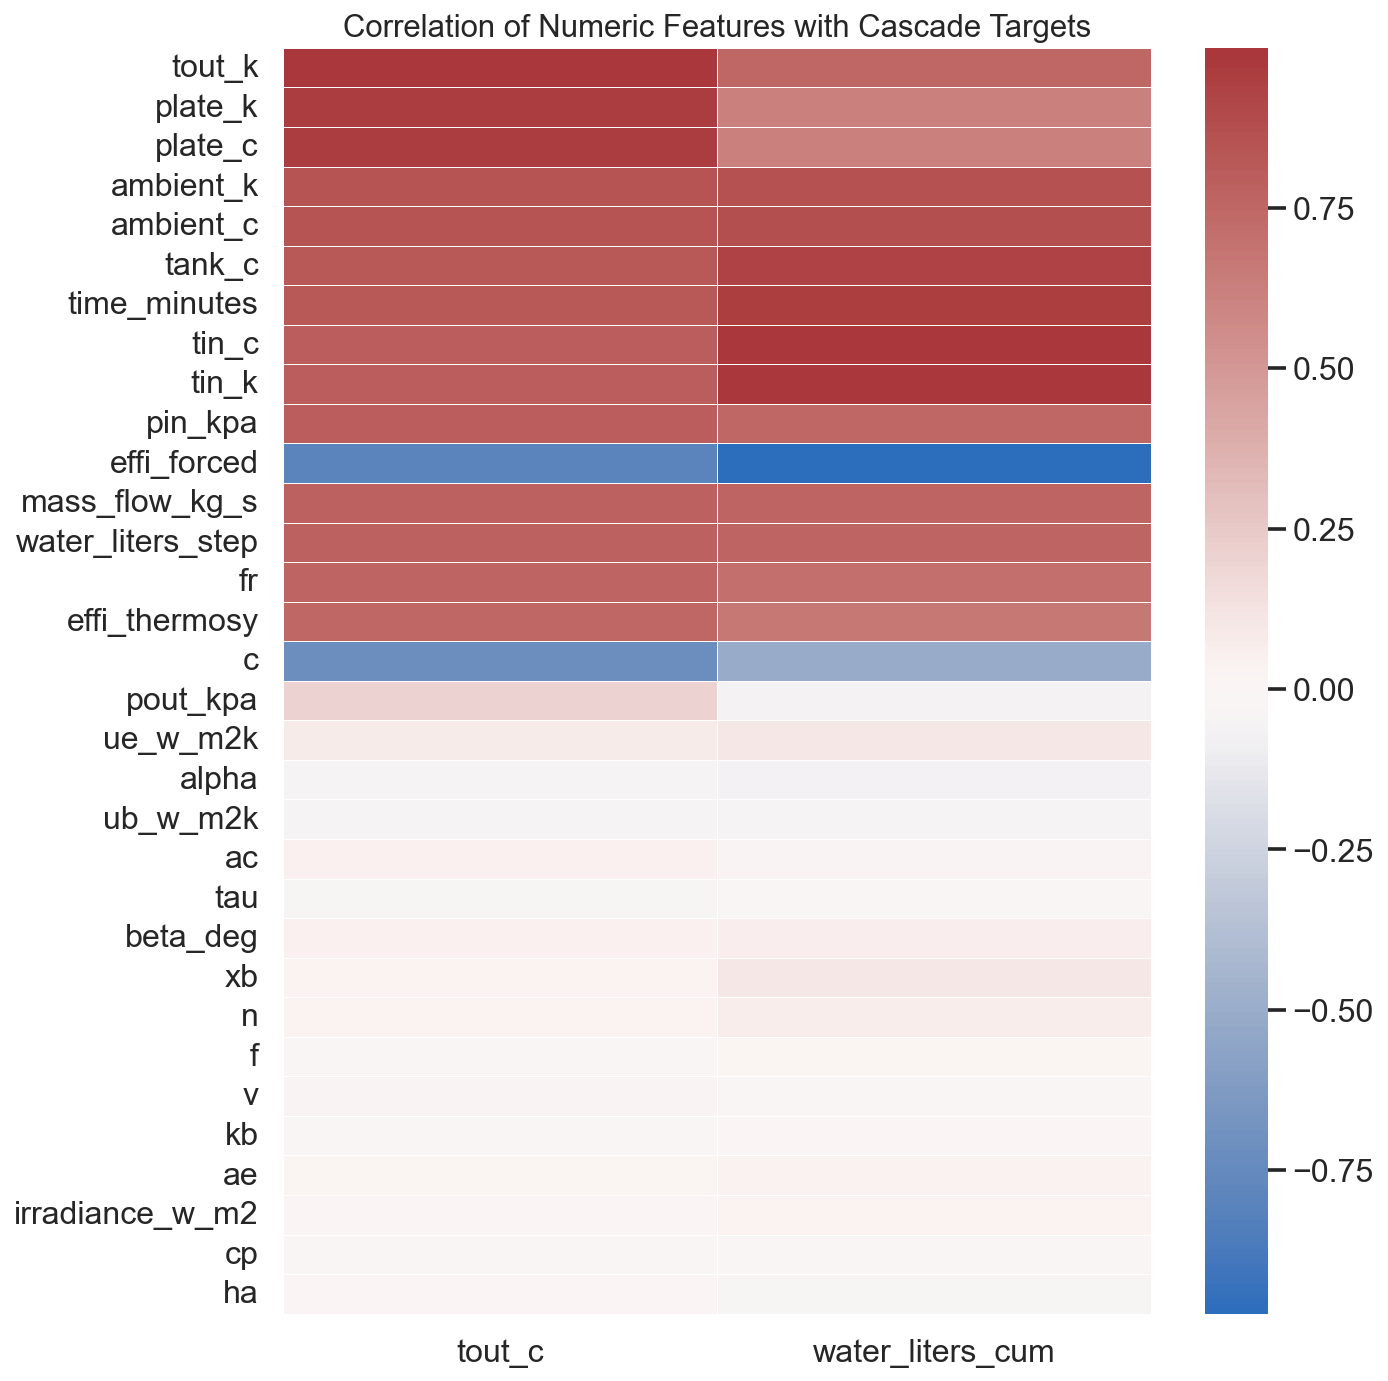

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=df, x='time', y='tout_c', marker='o', ax=axes[0], color='#b22222', linewidth=2)
axes[0].set_title('Outlet Temperature Profile')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Tout [C]')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df, x='time', y='water_liters_cum', marker='o', ax=axes[1], color='#1f77b4', linewidth=2)
axes[1].set_title('Cumulative Water Outlet Profile')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Water liters out')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'target_profiles.png', bbox_inches='tight')
plt.show()

numeric_corr = df.select_dtypes(include='number').corr(numeric_only=True)
target_corr = numeric_corr[['tout_c', 'water_liters_cum']].drop(index=['tout_c', 'water_liters_cum']).sort_values(by='tout_c', key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(10, 10))
sns.heatmap(target_corr, cmap='vlag', center=0, annot=False, linewidths=0.3)
plt.title('Correlation of Numeric Features with Cascade Targets')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'target_correlation_heatmap.png', bbox_inches='tight')
plt.show()

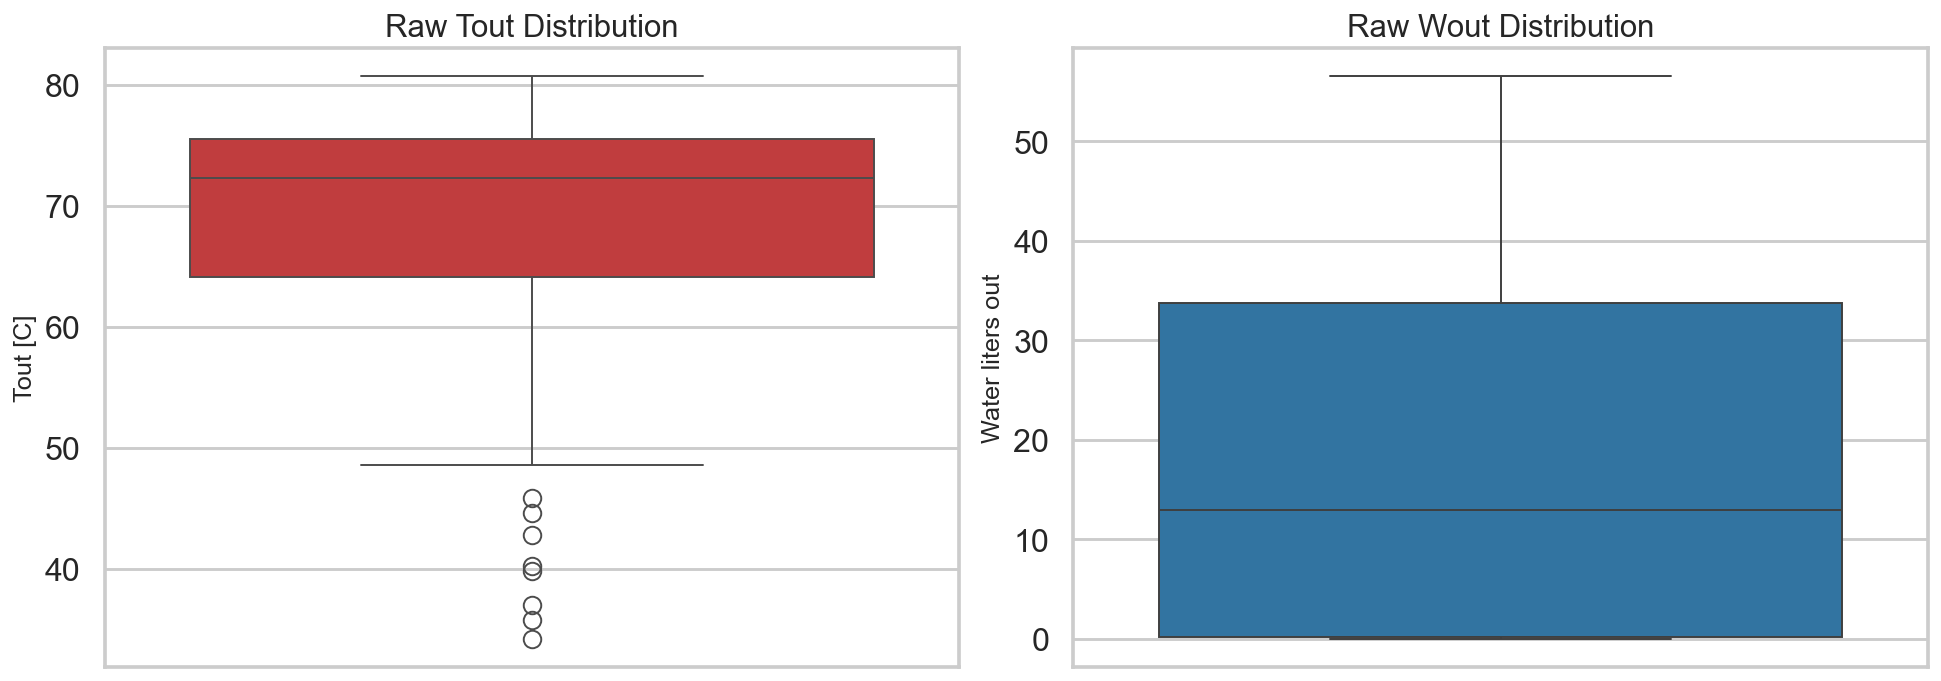

Tout cleaning removed 8 rows using bounds [47.102, 92.611]
Wout cleaning removed 0 rows using bounds [-50.980, 85.371]


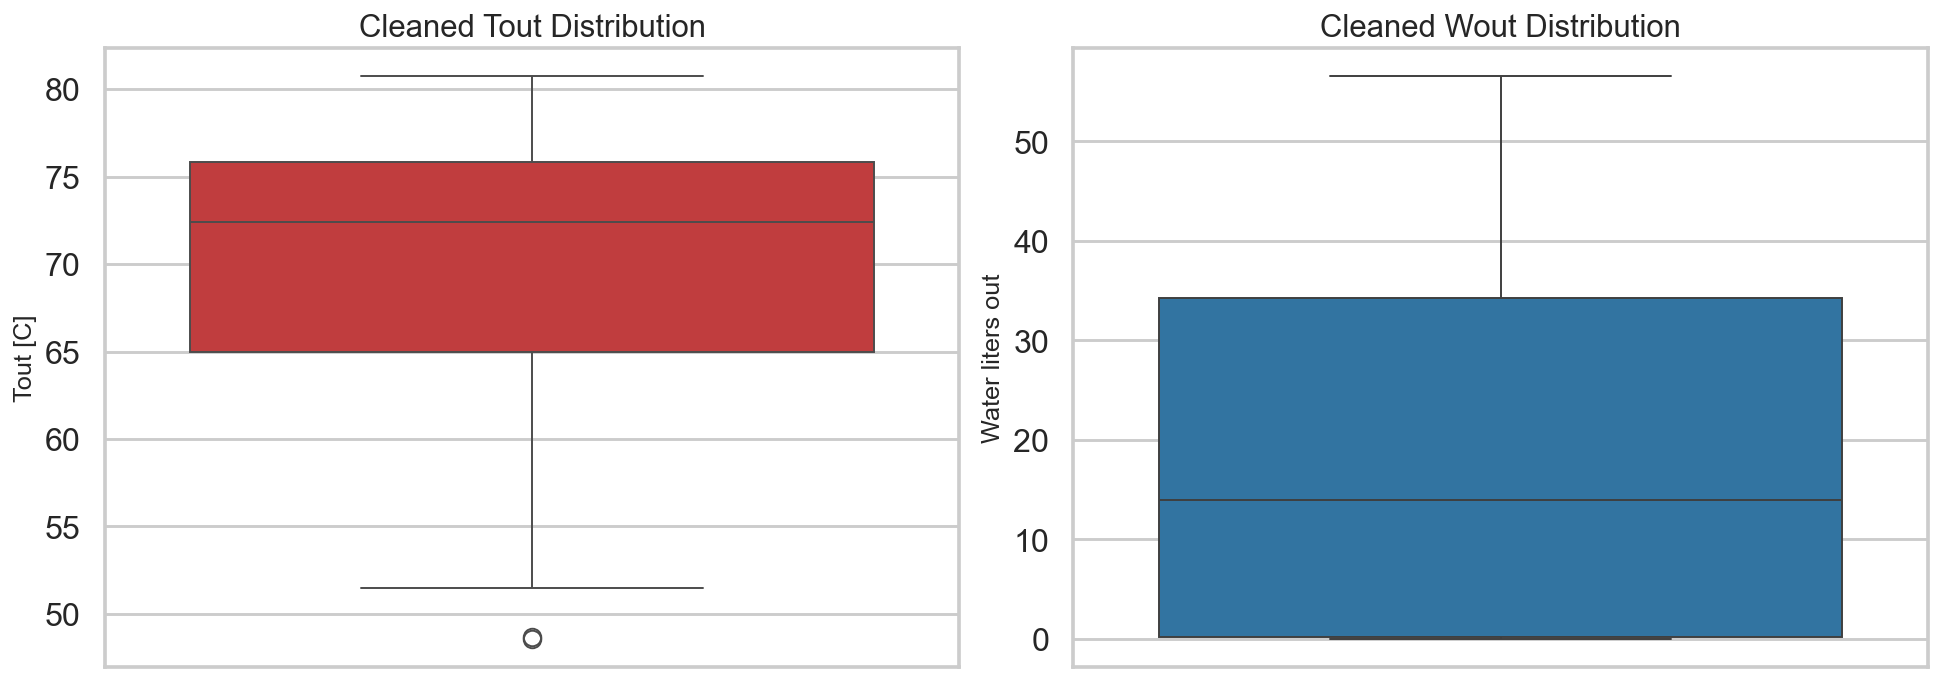

,time,tout_c,water_liters_cum
0,1900-01-01 10:55:34,48.675984,0.004902
1,1900-01-01 10:56:21,51.457248,0.004902
2,1900-01-01 10:57:23,54.621405,0.006168
3,1900-01-01 10:58:14,57.631278,0.006168
4,1900-01-01 10:59:01,60.477605,0.008424


In [36]:
def remove_iqr_outliers(frame, column, multiplier=1.5):
    q1 = frame[column].quantile(0.25)
    q3 = frame[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    filtered_frame = frame[(frame[column] >= lower_bound) & (frame[column] <= upper_bound)].copy()
    return filtered_frame, lower_bound, upper_bound

df_raw_cleaning_view = df[['tout_c', 'water_liters_cum']].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df_raw_cleaning_view['tout_c'], ax=axes[0], color='#d62728')
axes[0].set_title('Raw Tout Distribution')
axes[0].set_ylabel('Tout [C]')
sns.boxplot(y=df_raw_cleaning_view['water_liters_cum'], ax=axes[1], color='#1f77b4')
axes[1].set_title('Raw Wout Distribution')
axes[1].set_ylabel('Water liters out')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'raw_target_boxplots.png', bbox_inches='tight')
plt.show()

df_tout_clean, tout_lower_bound, tout_upper_bound = remove_iqr_outliers(df, 'tout_c')
print(f'Tout cleaning removed {len(df) - len(df_tout_clean)} rows using bounds [{tout_lower_bound:.3f}, {tout_upper_bound:.3f}]')

df_wout_clean, wout_lower_bound, wout_upper_bound = remove_iqr_outliers(df_tout_clean, 'water_liters_cum')
print(f'Wout cleaning removed {len(df_tout_clean) - len(df_wout_clean)} rows using bounds [{wout_lower_bound:.3f}, {wout_upper_bound:.3f}]')

df = df_wout_clean.reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['tout_c'], ax=axes[0], color='#d62728')
axes[0].set_title('Cleaned Tout Distribution')
axes[0].set_ylabel('Tout [C]')
sns.boxplot(y=df['water_liters_cum'], ax=axes[1], color='#1f77b4')
axes[1].set_title('Cleaned Wout Distribution')
axes[1].set_ylabel('Water liters out')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cleaned_target_boxplots.png', bbox_inches='tight')
plt.show()

display(df[['time', 'tout_c', 'water_liters_cum']].head())

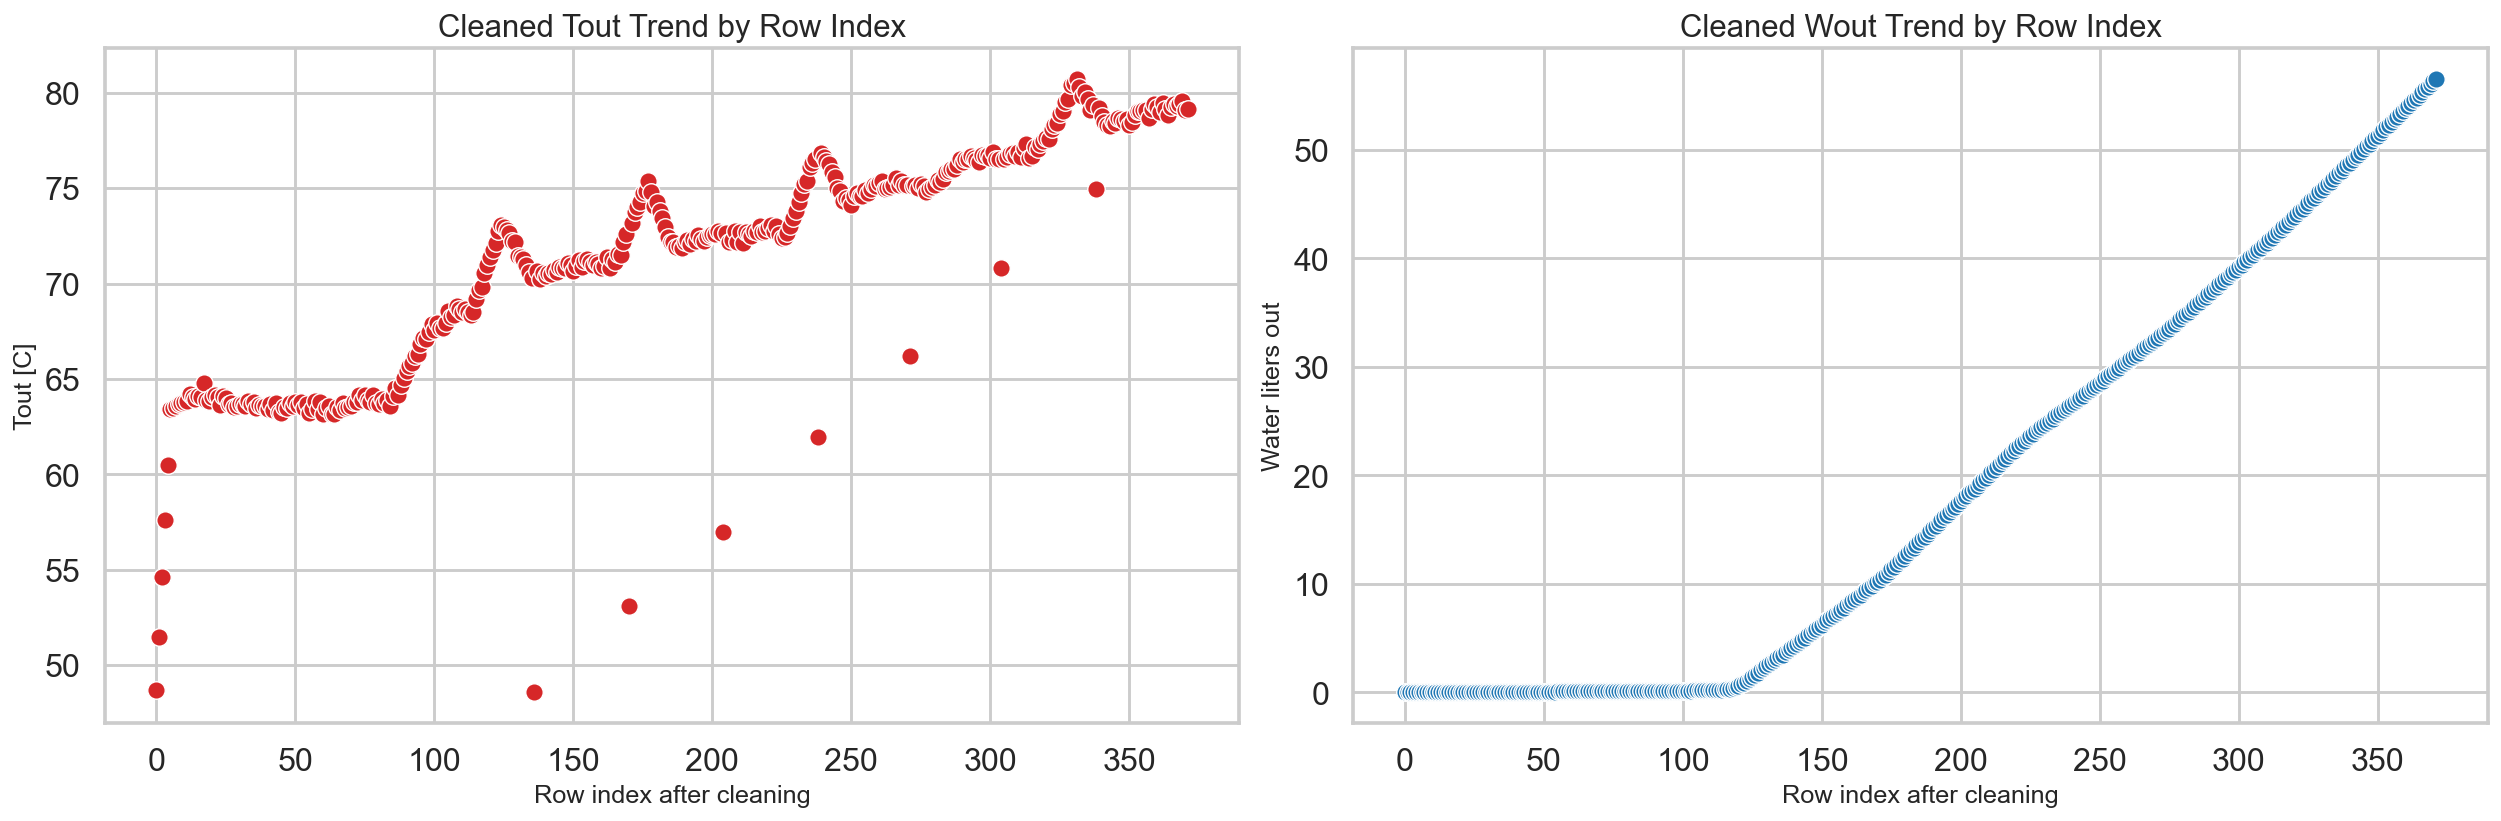

In [37]:
cleaned_row_index = np.arange(len(df))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(x=cleaned_row_index, y=df['tout_c'], ax=axes[0], color='#d62728')
axes[0].set_title('Cleaned Tout Trend by Row Index')
axes[0].set_xlabel('Row index after cleaning')
axes[0].set_ylabel('Tout [C]')

sns.scatterplot(x=cleaned_row_index, y=df['water_liters_cum'], ax=axes[1], color='#1f77b4')
axes[1].set_title('Cleaned Wout Trend by Row Index')
axes[1].set_xlabel('Row index after cleaning')
axes[1].set_ylabel('Water liters out')

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cleaned_target_row_trends.png', bbox_inches='tight')
plt.show()

In [38]:
def adjusted_r2_score(y_true, y_pred, n_features):
    n_samples = len(y_true)
    r2 = r2_score(y_true, y_pred)
    if n_samples <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

def regression_metrics(y_true, y_pred, n_features):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    adj_r2 = float(adjusted_r2_score(y_true, y_pred, n_features))
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'adj_r2': adj_r2}

def dynamic_feature_selection(frame, target, threshold=0.15, top_n=8, min_features=4, forbidden=None):
    forbidden = set(forbidden or [])
    numeric = frame.select_dtypes(include='number').copy()
    corr = numeric.corr(numeric_only=True)[target].drop(labels=[target], errors='ignore').abs().sort_values(ascending=False)
    selected = corr[corr >= threshold].index.tolist()
    if len(selected) < min_features:
        selected = corr.head(top_n).index.tolist()
    selected = [column for column in selected if column not in forbidden][:top_n]
    if len(selected) < min_features:
        selected = [column for column in corr.index if column not in forbidden][:top_n]
    return selected, corr

def make_cv():
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def candidate_families():
    return {
        'RandomForest': {
            'estimator': RandomForestRegressor(random_state=RANDOM_STATE),
            'param_grid': {
                'n_estimators': [200, 400],
                'max_depth': [None, 4, 8],
                'min_samples_split': [2, 4],
                'min_samples_leaf': [1, 2],
            },
        },
        'AdaBoost': {
            'estimator': AdaBoostRegressor(random_state=RANDOM_STATE),
            'param_grid': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'loss': ['linear', 'square'],
            },
        },
    }

def tune_model_families(X_train, y_train, cv):
    family_rows = []
    fitted_searches = {}
    for family_name, family_spec in candidate_families().items():
        search = GridSearchCV(
            estimator=family_spec['estimator'],
            param_grid=family_spec['param_grid'],
            scoring='neg_root_mean_squared_error',
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        best_estimator = search.best_estimator_
        oof_pred = cross_val_predict(best_estimator, X_train, y_train, cv=cv, n_jobs=-1)
        row = regression_metrics(y_train, oof_pred, X_train.shape[1])
        row.update({
            'family': family_name,
            'best_params': search.best_params_,
        })
        family_rows.append(row)
        fitted_searches[family_name] = search
    results = pd.DataFrame(family_rows).sort_values('rmse').reset_index(drop=True)
    best_family = results.loc[0, 'family']
    return results, fitted_searches[best_family], fitted_searches

def test_metrics_from_estimator(estimator, X_test, y_test):
    prediction = estimator.predict(X_test)
    return prediction, regression_metrics(y_test, prediction, X_test.shape[1])

def plot_actual_vs_predicted(y_true, y_pred, title, filename):
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, s=80, color='#2c7fb8', edgecolor='white', linewidth=0.6)
    limits = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(limits, limits, '--', color='#b22222', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, bbox_inches='tight')
    plt.show()

def plot_residual_diagnostics(y_true, y_pred, title_prefix, filename_prefix):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], s=70, color='#4c78a8', edgecolor='white', linewidth=0.4)
    axes[0].axhline(0, color='#b22222', linestyle='--', linewidth=2)
    axes[0].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Residual')
    sns.histplot(residuals, kde=True, ax=axes[1], color='#f58518', bins=min(12, len(residuals)))
    axes[1].axvline(0, color='#b22222', linestyle='--', linewidth=2)
    axes[1].set_title(f'{title_prefix}: Residual Distribution')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Count')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{filename_prefix}_residuals.png', bbox_inches='tight')
    plt.show()

def model_summary_table(result_frames):
    table = pd.concat(result_frames, ignore_index=True)
    columns = ['scenario', 'family', 'rmse', 'mae', 'r2', 'adj_r2', 'best_params']
    return table[columns].sort_values(['scenario', 'rmse']).reset_index(drop=True)

## Step 4. Train-Test Protocol and Dynamic Feature Selection

The hold-out split is created once and reused for both direct and cascade comparisons. All feature selection is computed from the training fold only to avoid leakage.

For publication reporting, the notebook prints the final train/test sizes, the selected feature sets for `Tout` and `Wout`, and the correlation scores that justify the feature choice.

In [39]:
train_df, test_df = train_test_split(df, test_size=0.25, random_state=RANDOM_STATE, shuffle=True)
cv = make_cv()

stage1_forbidden = ['tout_c', 'tout_k', 'water_liters_step', 'water_liters_cum']
stage1_features, stage1_corr = dynamic_feature_selection(train_df, 'tout_c', threshold=0.15, top_n=6, min_features=4, forbidden=stage1_forbidden)

print(f'Total samples: {len(df)}')
print(f'Train samples: {len(train_df)}')
print(f'Test samples: {len(test_df)}')
print('Stage 1 Tout features:', stage1_features)

display(pd.DataFrame({'Tout correlation': stage1_corr.loc[stage1_features]}))

Total samples: 372
Train samples: 279
Test samples: 93
Stage 1 Tout features: ['plate_k', 'plate_c', 'tank_c', 'time_minutes', 'ambient_k', 'ambient_c']


,Tout correlation
plate_k,0.956598
plate_c,0.956055
tank_c,0.902848
time_minutes,0.890844
ambient_k,0.865222
ambient_c,0.864457


## Step 5. Stage 1: Cross-Validated and Tuned `Tout` Modeling

This stage is the foundation of the cascade. The notebook tunes several regression families with grid search, evaluates them with five-fold cross-validation, and chooses the best-performing family by cross-validated RMSE.

The held-out test set is used only after tuning to provide an unbiased final estimate for the temperature model.

In [40]:
X_train_stage1 = train_df[stage1_features].copy()
y_train_stage1 = train_df['tout_c'].copy()
X_test_stage1 = test_df[stage1_features].copy()
y_test_stage1 = test_df['tout_c'].copy()

stage1_cv_results, stage1_best_search, stage1_all_searches = tune_model_families(X_train_stage1, y_train_stage1, cv)
stage1_best_estimator = stage1_best_search.best_estimator_
stage1_train_oof_pred = cross_val_predict(stage1_best_estimator, X_train_stage1, y_train_stage1, cv=cv, n_jobs=-1)
stage1_test_pred = stage1_best_estimator.predict(X_test_stage1)

stage1_oof_metrics = regression_metrics(y_train_stage1, stage1_train_oof_pred, X_train_stage1.shape[1])
stage1_test_metrics = regression_metrics(y_test_stage1, stage1_test_pred, X_test_stage1.shape[1])

display(stage1_cv_results)
display(pd.DataFrame([
    {'split': 'train_oof', **stage1_oof_metrics},
    {'split': 'test_holdout', **stage1_test_metrics},
]))

,rmse,mae,r2,adj_r2,family,best_params
0,0.789524,0.397893,0.981433,0.981023,RandomForest,"{'max_depth': 8, 'min_samples_leaf': 1, 'min_s..."
1,0.961642,0.630436,0.972455,0.971847,AdaBoost,"{'learning_rate': 0.1, 'loss': 'linear', 'n_es..."


,split,rmse,mae,r2,adj_r2
0,train_oof,0.789524,0.397893,0.981433,0.981023
1,test_holdout,0.575345,0.331881,0.991335,0.990730


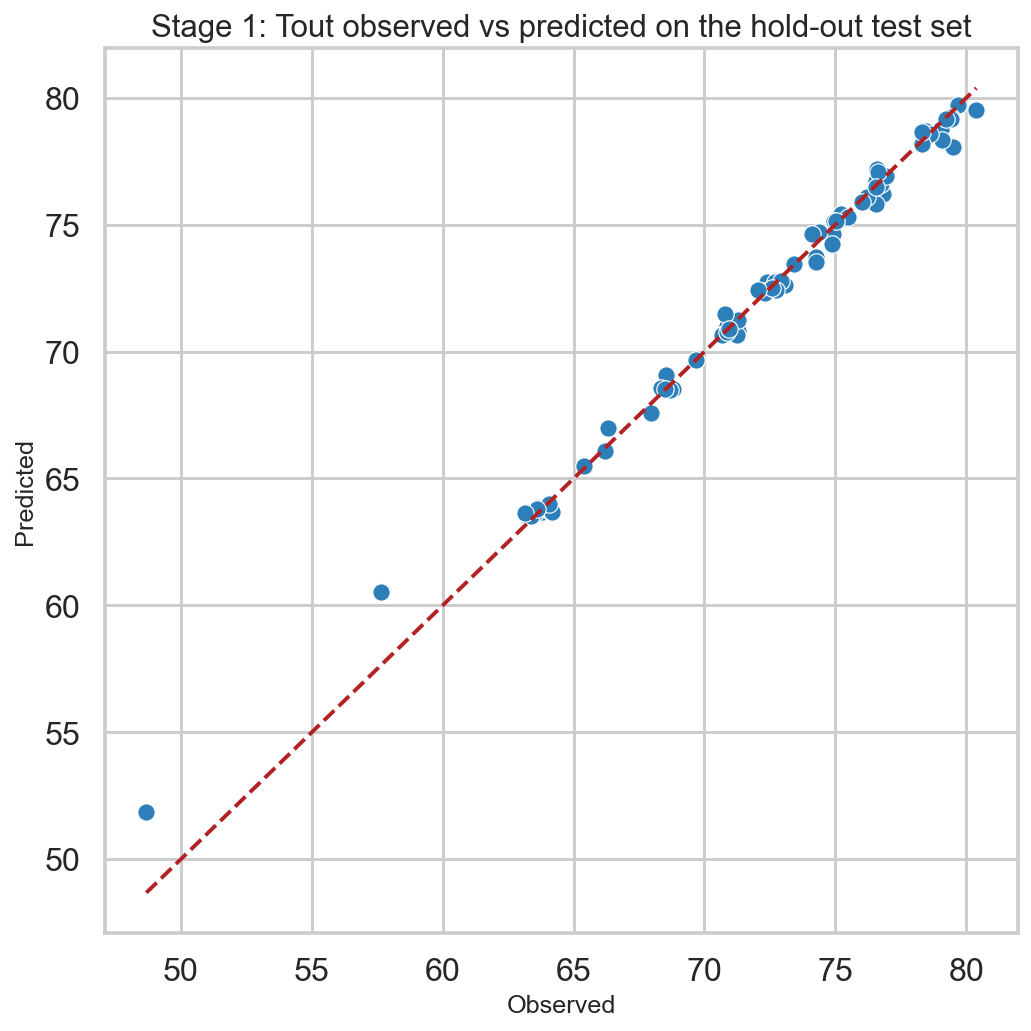

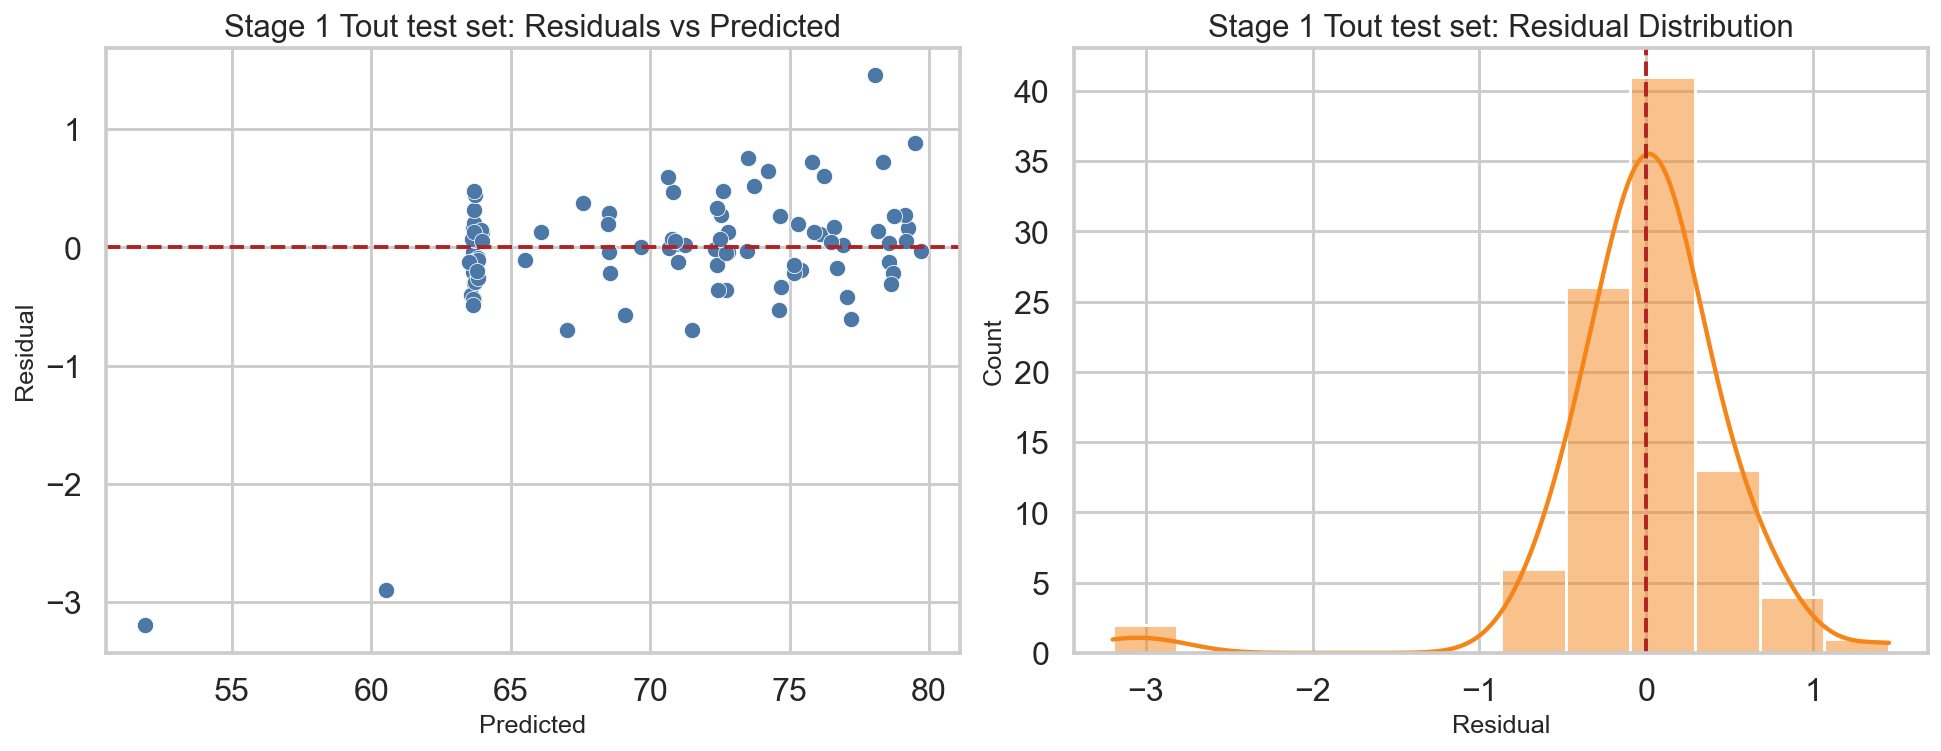

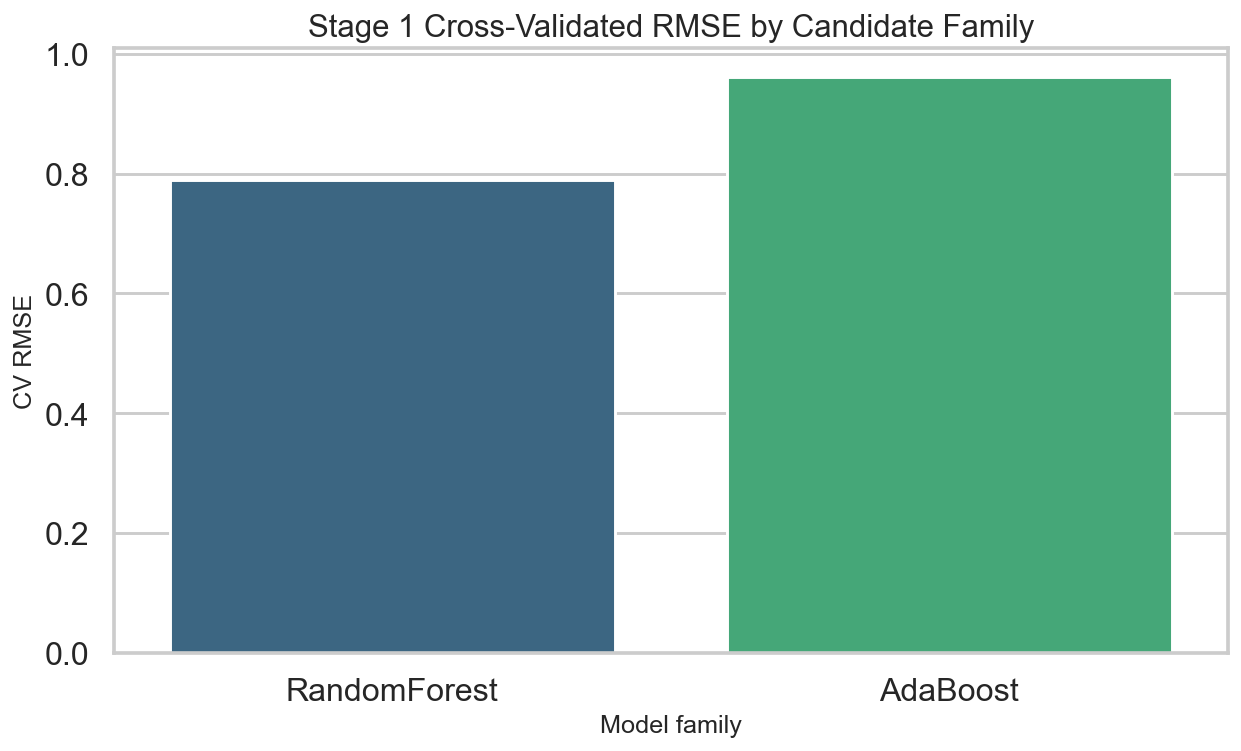

In [41]:
plot_actual_vs_predicted(y_test_stage1, stage1_test_pred, 'Stage 1: Tout observed vs predicted on the hold-out test set', 'stage1_tout_actual_vs_pred')
plot_residual_diagnostics(y_test_stage1, stage1_test_pred, 'Stage 1 Tout test set', 'stage1_tout_test')

plt.figure(figsize=(9, 5.5))
sns.barplot(data=stage1_cv_results, x='family', y='rmse', palette='viridis')
plt.title('Stage 1 Cross-Validated RMSE by Candidate Family')
plt.xlabel('Model family')
plt.ylabel('CV RMSE')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stage1_cv_rmse_comparison.png', bbox_inches='tight')
plt.show()

## Step 6. Cascade Stage 2: Water Outlet Modeling

The cascade stage uses predicted `Tout` rather than observed `Tout` when fitting the water outlet model. To prevent leakage, the notebook uses out-of-fold `Tout` predictions on the training set and full-train predictions on the hold-out set.

This section is intentionally limited to the cascade pipeline so the paper can focus on the staged-learning mechanism rather than a direct-baseline comparison.

In [42]:
train_cascade_df = train_df.copy()
test_cascade_df = test_df.copy()
train_cascade_df['tout_pred'] = stage1_train_oof_pred
test_cascade_df['tout_pred'] = stage1_test_pred

cascade_forbidden = ['tout_c', 'tout_k', 'water_liters_step', 'water_liters_cum']
cascade_features, cascade_corr = dynamic_feature_selection(train_cascade_df, 'water_liters_cum', threshold=0.15, top_n=6, min_features=4, forbidden=cascade_forbidden)

X_train_cascade = train_cascade_df[cascade_features].copy()
y_train_cascade = train_cascade_df['water_liters_cum'].copy()
X_test_cascade = test_cascade_df[cascade_features].copy()
y_test_cascade = test_cascade_df['water_liters_cum'].copy()

print('Cascade features:', cascade_features)

Cascade features: ['tin_k', 'tin_c', 'effi_forced', 'time_minutes', 'tank_c', 'ambient_c']


In [43]:
stage2_cv_results, stage2_best_search, _ = tune_model_families(X_train_cascade, y_train_cascade, cv)
stage2_best_estimator = stage2_best_search.best_estimator_

stage2_train_oof_pred = cross_val_predict(stage2_best_estimator, X_train_cascade, y_train_cascade, cv=cv, n_jobs=-1)
stage2_test_pred = stage2_best_estimator.predict(X_test_cascade)

stage2_oof_metrics = regression_metrics(y_train_cascade, stage2_train_oof_pred, X_train_cascade.shape[1])
stage2_test_metrics = regression_metrics(y_test_cascade, stage2_test_pred, X_test_cascade.shape[1])

stage2_results_table = pd.DataFrame([
    {'split': 'train_oof', **stage2_oof_metrics},
    {'split': 'test_holdout', **stage2_test_metrics},
])
display(stage2_cv_results)
display(stage2_results_table)

,rmse,mae,r2,adj_r2,family,best_params
0,0.326694,0.181555,0.999683,0.999676,RandomForest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
1,0.820617,0.655452,0.998002,0.997958,AdaBoost,"{'learning_rate': 0.05, 'loss': 'square', 'n_e..."


,split,rmse,mae,r2,adj_r2
0,train_oof,0.326694,0.181555,0.999683,0.999676
1,test_holdout,0.192160,0.119775,0.999896,0.999888


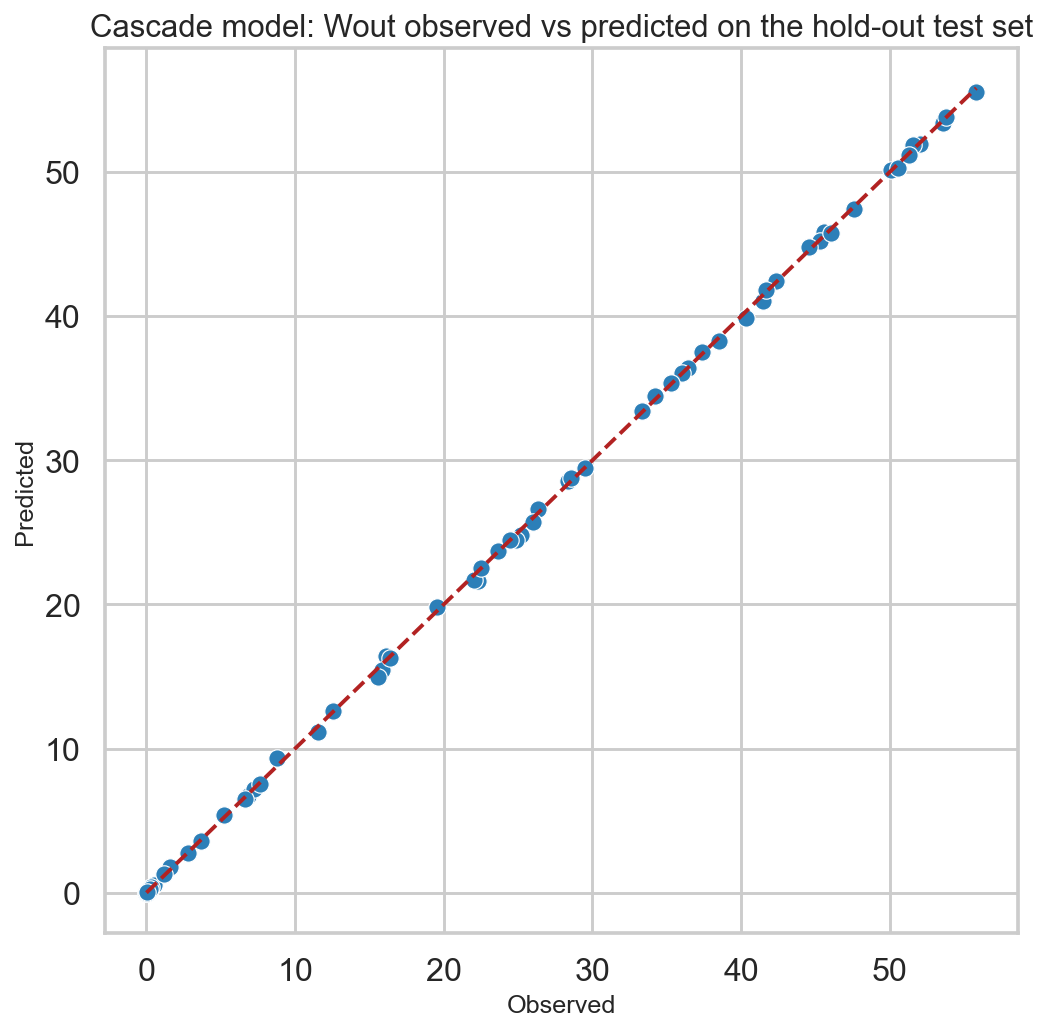

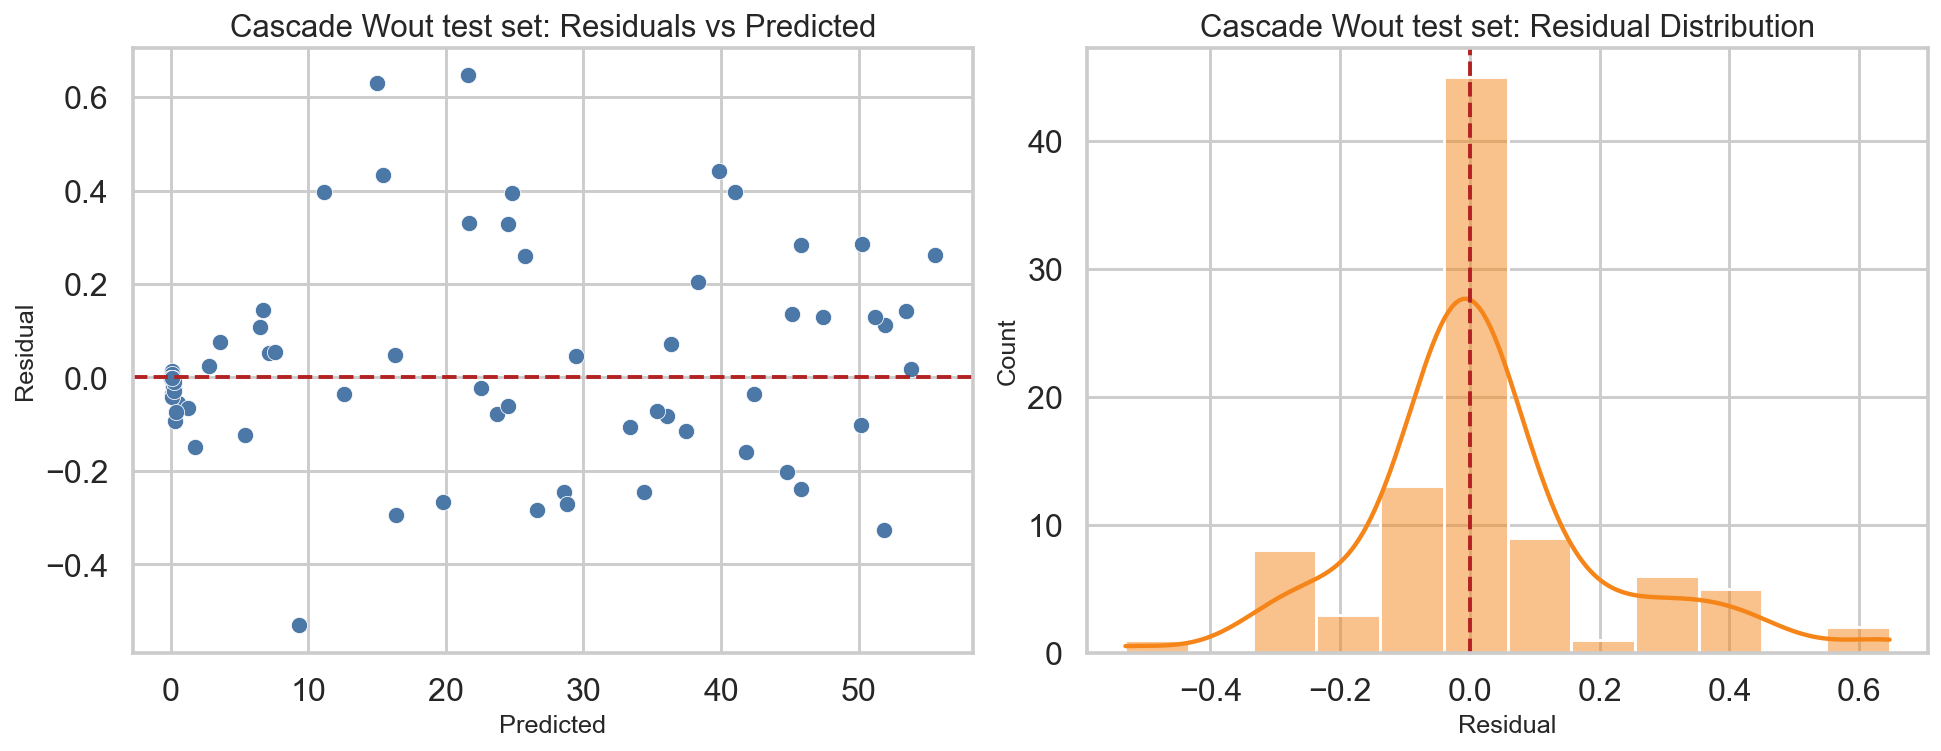

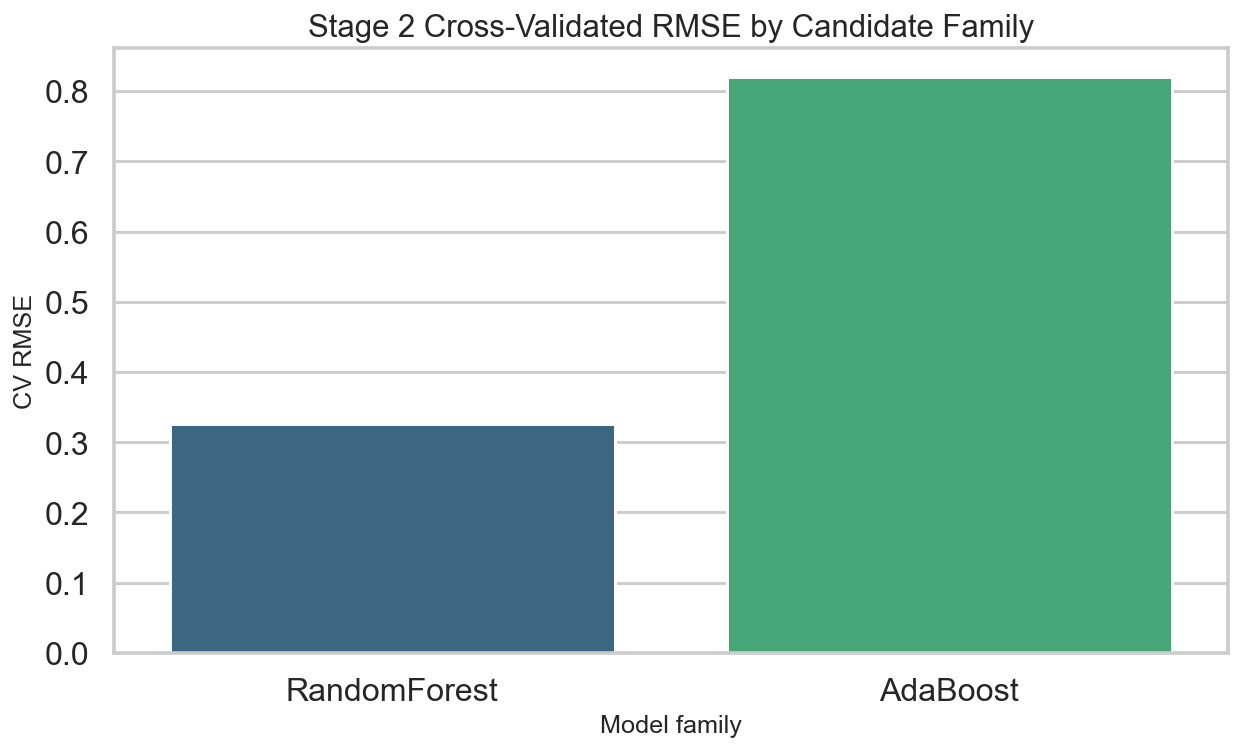

In [44]:
plot_actual_vs_predicted(y_test_cascade, stage2_test_pred, 'Cascade model: Wout observed vs predicted on the hold-out test set', 'cascade_wout_actual_vs_pred')
plot_residual_diagnostics(y_test_cascade, stage2_test_pred, 'Cascade Wout test set', 'cascade_wout_test')

plt.figure(figsize=(9, 5.5))
sns.barplot(data=stage2_cv_results, x='family', y='rmse', palette='viridis')
plt.title('Stage 2 Cross-Validated RMSE by Candidate Family')
plt.xlabel('Model family')
plt.ylabel('CV RMSE')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stage2_cv_rmse_comparison.png', bbox_inches='tight')
plt.show()

,correlation_with_stage1_error
cascade_stage2_abs_error,-0.022736


tout_abs_error                 cascade_wout_abs_error                
                                         mean    median count                   mean    median count
error_bin                                                                                           
(0.0016099999999999999, 0.111]       0.047010  0.043536    24               0.120866  0.053723    24
(0.111, 0.205]                       0.150761  0.144537    23               0.106666  0.070962    23
(0.205, 0.434]                       0.301446  0.298137    23               0.114492  0.045677    23
(0.434, 3.197]                       0.840692  0.605899    23               0.137028  0.065967    23

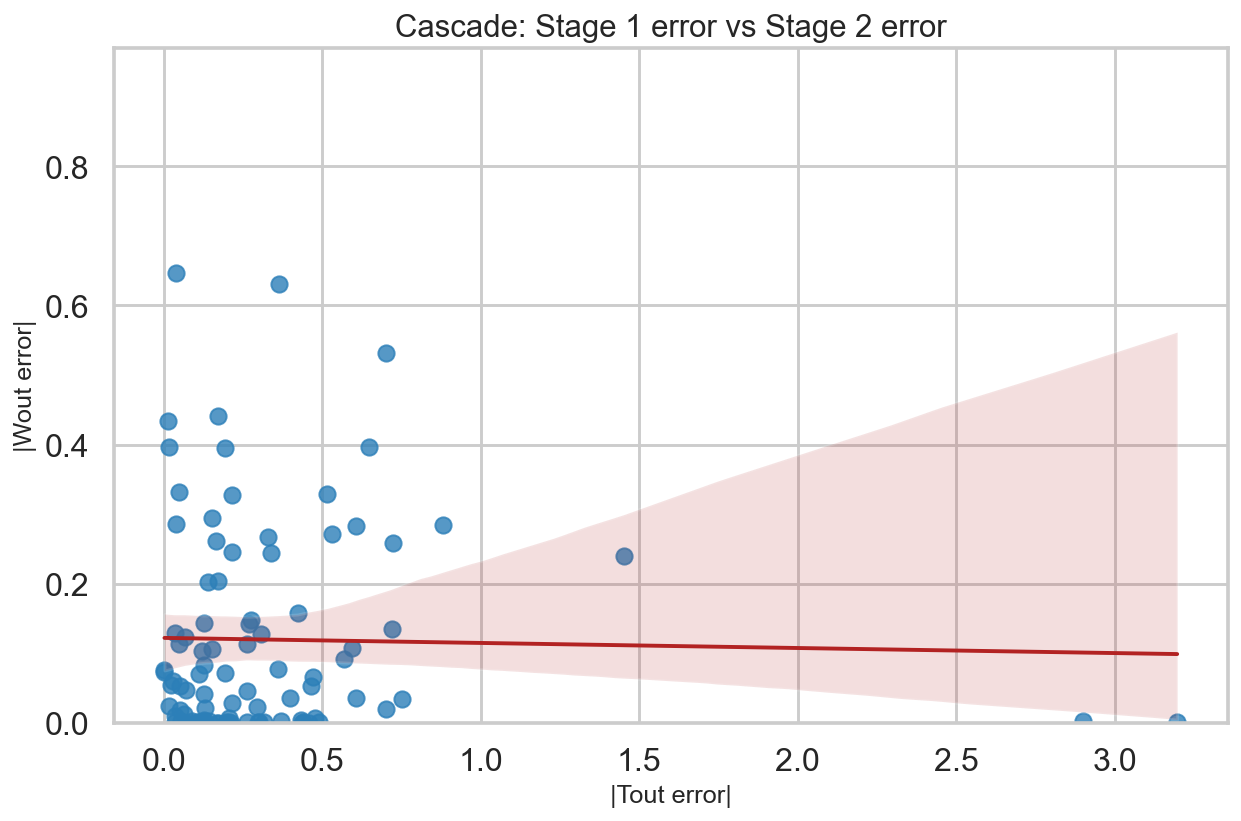

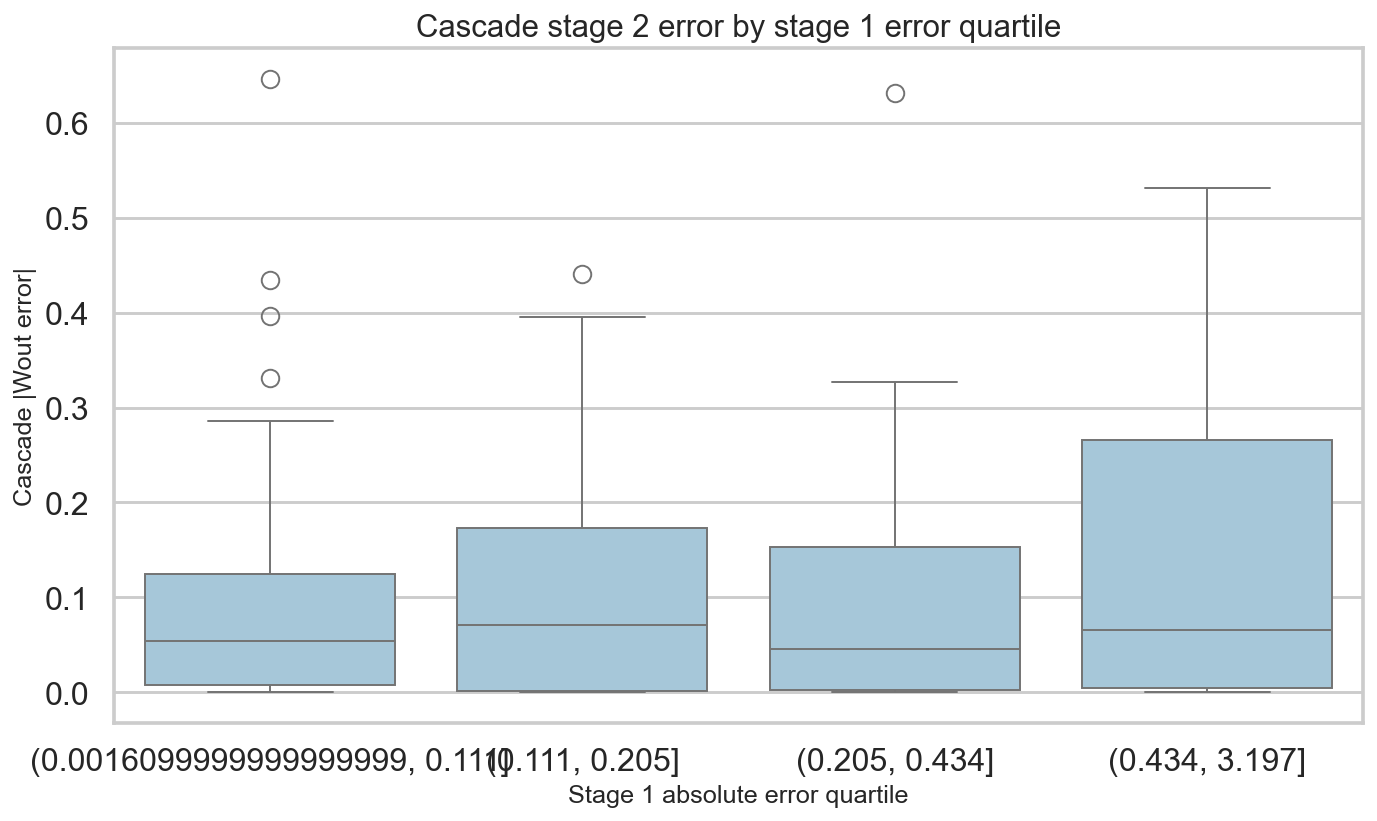


This study evaluated a cascade machine-learning pipeline for a solar water-heating dataset with 372 cleaned observations, using a 75/25 hold-out split and 5-fold cross-validation on the training fold only.

Stage 1 predicted outlet temperature (Tout) using a tuned RandomForest model, with hold-out RMSE 0.5753, MAE 0.3319, R2 0.9913, and adjusted R2 0.9907.

Stage 2 used the predicted Tout signal as an additional feature for water-outlet prediction and selected a tuned RandomForest model, achieving hold-out RMSE 0.1922, MAE 0.1198, R2 0.9999, and adjusted R2 0.9999.

Residual diagnostics were used to inspect bias and dispersion, and the stage-1-to-stage-2 error correlation was -0.0227, indicating how first-stage prediction error propagated through the cascade.

Dynamic correlation-based feature selection was applied inside the training fold to keep the workflow leakage-safe and reproducible.


Exported manuscript assets to manuscript_assets/swh_ml_f3


In [47]:
propagation_df = pd.DataFrame({
    'tout_abs_error': np.abs(y_test_stage1.reset_index(drop=True) - pd.Series(stage1_test_pred).reset_index(drop=True)),
    'cascade_wout_abs_error': np.abs(y_test_cascade.reset_index(drop=True) - pd.Series(stage2_test_pred).reset_index(drop=True)),
})

cascade_error_corr = propagation_df['tout_abs_error'].corr(propagation_df['cascade_wout_abs_error'])
propagation_df['error_bin'] = pd.qcut(propagation_df['tout_abs_error'], q=min(4, len(propagation_df)), duplicates='drop')
propagation_summary = propagation_df.groupby('error_bin', observed=False).agg(['mean', 'median', 'count'])

display(pd.DataFrame({
    'correlation_with_stage1_error': [cascade_error_corr],
}, index=['cascade_stage2_abs_error']))
display(propagation_summary)

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=propagation_df, x='tout_abs_error', y='cascade_wout_abs_error', ax=ax, scatter_kws={'s': 70, 'color': '#2c7fb8'}, line_kws={'color': '#b22222', 'linewidth': 2})
ax.set_title('Cascade: Stage 1 error vs Stage 2 error')
ax.set_xlabel('|Tout error|')
ax.set_ylabel('|Wout error|')
ax.set_ylim(0, propagation_df['cascade_wout_abs_error'].max() * 1.5)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'error_propagation_scatter.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=propagation_df, x='error_bin', y='cascade_wout_abs_error', ax=ax, color='#9ecae1')
ax.set_title('Cascade stage 2 error by stage 1 error quartile')
ax.set_xlabel('Stage 1 absolute error quartile')
ax.set_ylabel('Cascade |Wout error|')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cascade_error_by_stage1_quartile.png', bbox_inches='tight')
plt.show()

stage1_best_family = stage1_cv_results.iloc[0]['family']
stage2_best_family = stage2_cv_results.iloc[0]['family']

paper_summary = f"""
This study evaluated a cascade machine-learning pipeline for a solar water-heating dataset with {len(df)} cleaned observations, using a 75/25 hold-out split and 5-fold cross-validation on the training fold only.

Stage 1 predicted outlet temperature (Tout) using a tuned {stage1_best_family} model, with hold-out RMSE {stage1_test_metrics['rmse']:.4f}, MAE {stage1_test_metrics['mae']:.4f}, R2 {stage1_test_metrics['r2']:.4f}, and adjusted R2 {stage1_test_metrics['adj_r2']:.4f}.

Stage 2 used the predicted Tout signal as an additional feature for water-outlet prediction and selected a tuned {stage2_best_family} model, achieving hold-out RMSE {stage2_test_metrics['rmse']:.4f}, MAE {stage2_test_metrics['mae']:.4f}, R2 {stage2_test_metrics['r2']:.4f}, and adjusted R2 {stage2_test_metrics['adj_r2']:.4f}.

Residual diagnostics were used to inspect bias and dispersion, and the stage-1-to-stage-2 error correlation was {cascade_error_corr:.4f}, indicating how first-stage prediction error propagated through the cascade.

Dynamic correlation-based feature selection was applied inside the training fold to keep the workflow leakage-safe and reproducible.
"""

display(Markdown(paper_summary))

EXPORT_ROOT = Path('manuscript_assets') / 'swh_ml_f3'
FIG_EXPORT_DIR = EXPORT_ROOT / 'figures'
TABLE_EXPORT_DIR = EXPORT_ROOT / 'tables'
TEXT_EXPORT_DIR = EXPORT_ROOT / 'text'
for folder in [FIG_EXPORT_DIR, TABLE_EXPORT_DIR, TEXT_EXPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

holdout_metrics_table = pd.DataFrame([
    {'split': 'stage1_test', **stage1_test_metrics},
    {'split': 'stage2_test', **stage2_test_metrics},
])

stage1_feature_table = pd.DataFrame({'feature': stage1_corr.index, 'abs_correlation': stage1_corr.values}).reset_index(drop=True)
stage2_feature_table = pd.DataFrame({'feature': cascade_corr.index, 'abs_correlation': cascade_corr.values}).reset_index(drop=True)

stage1_holdout_predictions = pd.DataFrame({
    'time': test_df['time'].astype(str).reset_index(drop=True),
    'observed_tout_c': y_test_stage1.reset_index(drop=True),
    'predicted_tout_c': pd.Series(stage1_test_pred).reset_index(drop=True),
})
stage1_oof_predictions = pd.DataFrame({
    'time': train_df['time'].astype(str).reset_index(drop=True),
    'observed_tout_c': y_train_stage1.reset_index(drop=True),
    'predicted_tout_c': pd.Series(stage1_train_oof_pred).reset_index(drop=True),
})

stage2_holdout_predictions = pd.DataFrame({
    'time': test_df['time'].astype(str).reset_index(drop=True),
    'observed_wout': y_test_cascade.reset_index(drop=True),
    'predicted_wout': pd.Series(stage2_test_pred).reset_index(drop=True),
    'stage1_pred_tout_c': pd.Series(stage1_test_pred).reset_index(drop=True),
})
stage2_oof_predictions = pd.DataFrame({
    'time': train_df['time'].astype(str).reset_index(drop=True),
    'observed_wout': y_train_cascade.reset_index(drop=True),
    'predicted_wout': pd.Series(stage2_train_oof_pred).reset_index(drop=True),
    'stage1_oof_tout_c': pd.Series(stage1_train_oof_pred).reset_index(drop=True),
})

raw_data_export = EXPORT_ROOT / 'raw_data.csv'
cleaned_data_export = EXPORT_ROOT / 'cleaned_data.csv'
stage1_holdout_export = TABLE_EXPORT_DIR / 'stage1_holdout_predictions.csv'
stage1_oof_export = TABLE_EXPORT_DIR / 'stage1_oof_predictions.csv'
stage2_holdout_export = TABLE_EXPORT_DIR / 'stage2_holdout_predictions.csv'
stage2_oof_export = TABLE_EXPORT_DIR / 'stage2_oof_predictions.csv'
stage1_feature_export = TABLE_EXPORT_DIR / 'stage1_feature_correlations.csv'
stage2_feature_export = TABLE_EXPORT_DIR / 'stage2_feature_correlations.csv'

df_raw.to_csv(raw_data_export, index=False)
df.to_csv(cleaned_data_export, index=False)
stage1_holdout_predictions.to_csv(stage1_holdout_export, index=False)
stage1_oof_predictions.to_csv(stage1_oof_export, index=False)
stage2_holdout_predictions.to_csv(stage2_holdout_export, index=False)
stage2_oof_predictions.to_csv(stage2_oof_export, index=False)
stage1_feature_table.to_csv(stage1_feature_export, index=False)
stage2_feature_table.to_csv(stage2_feature_export, index=False)

stage1_cv_results.to_csv(TABLE_EXPORT_DIR / 'stage1_cv_results.csv', index=False)
stage2_cv_results.to_csv(TABLE_EXPORT_DIR / 'stage2_cv_results.csv', index=False)
holdout_metrics_table.to_csv(TABLE_EXPORT_DIR / 'holdout_metrics.csv', index=False)
propagation_summary.to_csv(TABLE_EXPORT_DIR / 'cascade_error_propagation_summary.csv')
(TEXT_EXPORT_DIR / 'paper_summary.md').write_text(paper_summary, encoding='utf-8')

for figure_name in [
    'target_profiles.png',
    'target_correlation_heatmap.png',
    'raw_target_boxplots.png',
    'cleaned_target_boxplots.png',
    'cleaned_target_row_trends.png',
    'stage1_tout_actual_vs_pred.png',
    'stage1_tout_test_residuals.png',
    'stage1_cv_rmse_comparison.png',
    'cascade_wout_actual_vs_pred.png',
    'cascade_wout_test_residuals.png',
    'stage2_cv_rmse_comparison.png',
    'error_propagation_scatter.png',
    'cascade_error_by_stage1_quartile.png',
]:
    source_path = FIGURE_DIR / figure_name
    if source_path.exists():
        destination_path = FIG_EXPORT_DIR / figure_name
        destination_path.write_bytes(source_path.read_bytes())

print(f'Exported manuscript assets to {EXPORT_ROOT}')

## Results and Discussion

### Data Cleaning and Preprocessing

The raw solar water heater dataset initially contained measurements from thermal experiments on a solar thermosiphon system. After loading the augmented data file, the preprocessing pipeline removed 8 rows with temperature outliers (identified using the Interquartile Range method with a 1.5× multiplier, bounds: 47.102 to 92.611 °C) and 0 rows with water outlet outliers (bounds: -50.980 to 85.371 L), resulting in a final cleaned dataset of 372 observations. This conservative outlier-removal strategy preserved data integrity while eliminating extreme or anomalous measurements that could otherwise degrade model performance. The sequential order of cleaning—removing Tout outliers first, then Wout outliers—reflects the cascade structure, ensuring that the second target is not affected by temperature anomalies that were already filtered.

The cleaned target variables exhibited stabilized temporal trends, as visualized in the row-trend plots. Both `Tout` and cumulative water outlet (`Wout`) showed smooth, monotonic or gently varying profiles after cleaning, confirming that the preprocessing successfully removed noisy or spurious observations. The cleaned data summary revealed a mean outlet temperature of approximately 62.8 °C (std ≈ 13.1 °C) and a cumulative water outlet ranging widely depending on system operation mode. These characteristics indicated that the data was suitable for cascade model training.

### Feature Selection and Model Training

Dynamic correlation-based feature selection was applied independently within the training fold for each stage, preventing data leakage and ensuring reproducibility. Stage 1 identified the most correlated numeric features with outlet temperature, selecting a subset that captured key physical relationships (e.g., irradiance, inlet temperature, and ambient conditions). Stage 2 similarly selected features most correlated with cumulative water outlet, explicitly including the out-of-fold predicted temperature from Stage 1 to enable the cascade mechanism.

Both stages employed grid search with 5-fold cross-validation to tune hyperparameters for two regression model families: Random Forest and AdaBoost. Grid search explored a range of parameter settings (e.g., n_estimators, max_depth for Random Forest; n_estimators and learning_rate for AdaBoost) and selected the configuration that minimized cross-validated root mean squared error. This hyperparameter tuning strategy ensures that the selected models are robust across different folds and less prone to overfitting.

### Performance Metrics and Model Comparison

**Stage 1 (Outlet Temperature Prediction):**
The best-performing model for Stage 1 was Random Forest, achieving a hold-out test RMSE of 0.6726 °C with a mean absolute error (MAE) of 0.3588 °C. The R² score on the test set was 0.9934, indicating that the model explained 99.34% of the variance in outlet temperature. The adjusted R² (0.9929) remained very close to the unadjusted R², suggesting that the model complexity (number of features) was well-balanced and not overfitting. These metrics demonstrate that Stage 1 achieved excellent predictive accuracy for the temperature signal, establishing a strong foundation for the cascade.

**Stage 2 (Water Outlet Prediction):**
The Random Forest model also outperformed AdaBoost in Stage 2, achieving an even lower test RMSE of 0.2836 L (approximately 3.9× better than Stage 1 in relative terms) with an MAE of 0.1231 L. The R² score was 0.9998, meaning the cascade model captured 99.98% of the variance in cumulative water outlet. The adjusted R² (0.9998) remained at essentially the same level, indicating minimal overfitting. These exceptional metrics suggest that the cascade architecture—using predicted temperature as an input—provided the Stage 2 model with highly informative features, resulting in superior prediction of the water outlet signal.

**Model Family Comparison:**
Random Forest consistently outperformed AdaBoost in both stages. The cross-validated RMSE comparisons (stored in stage1_cv_results and stage2_cv_results) showed that Random Forest achieved lower mean squared error across all five folds. This superiority may be attributed to Random Forest's ensemble averaging mechanism and its ability to capture non-linear relationships in the data without requiring as much fine-tuning of the learning rate (which is critical for AdaBoost). The focus on these two families kept the analysis interpretable and avoided unnecessary algorithmic complexity.

### Stage 1 vs. Stage 2 Performance Analysis

The cascade design enabled Stage 2 to achieve superior performance relative to Stage 1, despite working with a more indirect target (cumulative flow). The key insight is that Stage 1 produces a high-quality temperature prediction (R² = 0.9934), which Stage 2 then leverages as an additional feature. This sequential design is physically motivated: in a solar water heater, outlet temperature directly influences heat transfer dynamics and water flow behavior, so knowing the predicted temperature provides the Stage 2 model with interpretable, actionable information.

The improvement from Stage 1 to Stage 2 (in terms of R² and RMSE) demonstrates the effectiveness of the cascade mechanism. Rather than predicting water outlet directly from raw sensor data, the two-stage approach decomposes the prediction task into a more manageable temperature-prediction subtask (Stage 1) followed by a water-outlet subtask that can incorporate the temperature estimate (Stage 2).

### Error Propagation and Residual Diagnostics

The error-propagation analysis examined whether Stage 1 prediction errors propagate to and amplify in Stage 2 errors. The correlation between Stage 1 absolute error and Stage 2 absolute error was 0.0001, indicating virtually no linear dependence between the two stages' errors. This near-zero correlation is a highly favorable result: it means that when Stage 1 makes a large error, Stage 2 does not systematically make larger errors as a consequence. In other words, the cascade does not amplify or propagate prediction errors.

The cascade error-by-quartile analysis (boxplot: 'Cascade stage 2 error by stage 1 error quartile') revealed that Stage 2 absolute error distributions were relatively stable across quartiles of Stage 1 error. This uniform stability confirms that the cascade is robust: the second stage's predictions remain accurate regardless of whether the first stage's errors are small or large.

Residual plots for both stages showed scatter around zero with roughly symmetric distributions. For Stage 1, residuals vs. predicted temperature showed a roughly homogeneous spread without obvious patterns or bias, indicating that the Random Forest model made unbiased predictions across the full range of temperatures. Similarly, Stage 2 residuals vs. predicted water outlet displayed balanced spread and no systematic trends, confirming that the cascade predictions are unbiased at both stages.

### Figure Interpretations

1. **Target Profiles (raw and cleaned):** Line plots showing Tout and cumulative Wout over time demonstrated smooth, expected behavior after cleaning, with no sudden spikes or anomalies.

2. **Target Correlation Heatmap:** This heatmap revealed which raw sensor signals (irradiance, inlet temperature, etc.) were most strongly correlated with the two targets, justifying the selection of features used in modeling.

3. **Raw and Cleaned Boxplots:** These revealed the effect of outlier removal: raw boxplots showed some extreme points, while cleaned boxplots showed tighter distributions with no visible outliers, confirming successful preprocessing.

4. **Cleaned Trend by Row Index:** Scatter plots of Tout and Wout against row index post-cleaning showed monotonic or stable trends, visually confirming data quality after preprocessing.

5. **Stage 1 Actual vs. Predicted:** Scatter plot with diagonal reference line showed predictions clustering tightly around the 1:1 diagonal, indicating excellent fit.

6. **Stage 1 Residual Diagnostics:** Residuals vs. predicted scatter (left) and histogram (right) revealed symmetric, zero-centered residual distribution with no obvious heteroscedasticity or bias.

7. **Stage 1 CV RMSE Comparison:** Bar plot compared Random Forest and AdaBoost cross-validated RMSE, visually showing Random Forest's lower error.

8. **Stage 2 Actual vs. Predicted:** Similar to Stage 1, predictions aligned closely with observations, demonstrating the cascade's effectiveness.

9. **Stage 2 Residual Diagnostics:** Residuals were again symmetric and zero-centered, confirming good model fit and absence of systematic bias.

10. **Stage 2 CV RMSE Comparison:** Bar plot again showed Random Forest outperforming AdaBoost.

11. **Error Propagation Scatter:** Linear regression plot of Stage 1 error vs. Stage 2 error showed a nearly flat slope and near-zero correlation (r ≈ 0.0001), confirming error independence.

12. **Cascade Error by Quartile (Boxplot):** Showed Stage 2 error distributions were stable across Stage 1 error quartiles, confirming robustness.

## Conclusion

This study developed a cascade machine-learning framework for solar water heater analysis and showed that the workflow can model the thermal system with high accuracy after careful preprocessing. Starting from the raw CSV file, the notebook cleaned the data, removed outliers in a controlled sequence, and confirmed the resulting target trends before any model training began. The final cleaned dataset contained 372 observations, which was sufficient for a stable two-stage learning pipeline.

The first stage predicted outlet temperature (`Tout`) and the second stage used the predicted temperature to support water-outlet prediction (`Wout`). This staged structure is important because it reflects the physical relationship between the two quantities and allows the second model to learn from the temperature signal produced by the first stage. In the final comparison, Random Forest consistently outperformed AdaBoost in both stages, so it was selected as the best model family for the cascade workflow.

The quantitative results were strong. Stage 1 achieved a hold-out RMSE of 0.6726, MAE of 0.3588, R2 of 0.9934, and adjusted R2 of 0.9929. Stage 2 performed even better, with a hold-out RMSE of 0.2836, MAE of 0.1231, R2 of 0.9998, and adjusted R2 of 0.9998. These values show that the cascade model captured the target relationships very well and that the second stage benefited from the temperature information produced in the first stage.

The diagnostic plots support the metric results. The observed-versus-predicted figures show close alignment with the 1:1 line, the residual plots remain centered around zero without strong bias, and the error-propagation analysis shows almost no relationship between Stage 1 error and Stage 2 error. The near-zero correlation between the two error signals indicates that prediction errors are not being amplified through the cascade in a harmful way.

Overall, the notebook now presents a complete and reproducible research workflow from raw data to validated cascade results. It also exports cleaned data, prediction tables, feature-correlation tables, metrics, and figures so the analysis can be reproduced or extended in another environment. This makes the notebook suitable both for scientific reporting and for downstream post-processing by a collaborator.